In [1]:
import pandas as pd
import polars as pl

# Precision/Recall/F1

Generate precision/recall/f1 scores for the test run of wags-llm. This could be used to improve tooling or perform prompt engineering.

### Load Data


Load in the excel files

In [2]:
results_df = pd.read_csv('2026-06-15-interaction_classifications-bcl2.csv',sep=',')
context_df = pd.read_excel('../2026-06-08-test1-BCL2-only.xlsx')

truth_df = context_df.copy()
pred_df = results_df.copy()

In [3]:
pred_df.head()

,run_idx,prompt_version,temperature,pmid,block_id,skipped,skip_reason,candidate_drugs,candidate_genes,candidate_drug_count,candidate_gene_count,num_candidate_pairs,drug,gene,interaction,interaction_type,directionality,evidence,error_message
0,0,v2,0,14977850,0,False,NaN,TRAIL;doxorubicin hydrochloride;etoposide;oxal...,TNFSF10,4,1,4,TRAIL,BCL2,True,resistance modulation,inhibiting,NaN,NaN
1,0,v2,0,14977850,0,False,NaN,TRAIL;doxorubicin hydrochloride;etoposide;oxal...,TNFSF10,4,1,4,doxorubicin hydrochloride,BCL2,True,resistance,inhibitory,NaN,NaN
2,0,v2,0,14977850,0,False,NaN,TRAIL;doxorubicin hydrochloride;etoposide;oxal...,TNFSF10,4,1,4,etoposide,BCL2,True,resistance,inhibitory,NaN,NaN
3,0,v2,0,14977850,0,False,NaN,TRAIL;doxorubicin hydrochloride;etoposide;oxal...,TNFSF10,4,1,4,oxaliplatin,BCL2,True,resistance,inhibiting,NaN,NaN
4,0,v2,0,16684279,1,False,NaN,MPA;calcipotriene,TP53,2,1,2,MPA,BCL2,True,expression modulation,activating,NaN,NaN


In [4]:
truth_df.head()

,Unnamed: 0,pmid,drug_name,gene_name,drug_concept_id,sources,context
0,0,14977850,OXALIPLATIN,BCL2,rxcui:32592,ClearityFoundationBiomarkers; NCI,PURPOSE: Overexpression of antiapoptotic Bcl-2...
1,1,16684279,METHYLPREDNISOLONE,BCL2,rxcui:6902,NCI,OBJECTIVE: The decrease of physiological apopt...
2,2,16141680,METHYLPREDNISOLONE,BCL2,rxcui:6902,NCI,"Cardiac injury, occurred after traumatic brain..."
3,3,24749893,NAVITOCLAX,BCL2,ncit:C64776,ChEMBL; DTC; TALC; TTD,"Mcl-1, an antiapoptotic member of the Bcl-2 fa..."
4,4,12576461,EPIDERMAL GROWTH FACTOR RECEPTOR TYROSINE KINA...,BCL2,ncit:C2167,NCI,PURPOSE: This study investigated whether the f...


In [5]:
pred_df['gene'].value_counts()

gene
BCL2    227
Name: count, dtype: int64

Analysis

In [6]:
truth = truth_df.copy()
pred = pred_df.copy()

truth["drug"] = truth["drug_name"].str.upper().str.strip()
truth["gene"] = truth["gene_name"].str.upper().str.strip()

pred["drug"] = pred["drug"].str.upper().str.strip()
pred["gene"] = pred["gene"].str.upper().str.strip()

In [7]:
truth_pairs = (
    truth[
        ["pmid", "drug", "gene"]
    ]
    .drop_duplicates()
)

truth_pairs["truth"] = True

In [8]:
pred_pairs = (
    pred[
        ["pmid", "drug", "gene", "interaction"]
    ]
    .drop_duplicates()
)

pred_pairs = pred_pairs.rename(
    columns={"interaction": "predicted"}
)

In [9]:
pred_pairs = pred_pairs.dropna(subset=["pmid", "drug", "gene"])
truth_pairs = truth_pairs.dropna(subset=["pmid", "drug", "gene"])

In [10]:
eval_df = pred_pairs.merge(
    truth_pairs,
    on=["pmid", "drug", "gene"],
    how="left"
)

eval_df["truth"] = eval_df["truth"].fillna(False)

/var/folders/5t/sfw5tjx56m10xb861_pd3wfm0000gq/T/ipykernel_76716/1255973576.py:7: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  eval_df["truth"] = eval_df["truth"].fillna(False)


In [19]:
pred_df

,run_idx,prompt_version,temperature,pmid,block_id,skipped,skip_reason,candidate_drugs,candidate_genes,candidate_drug_count,candidate_gene_count,num_candidate_pairs,drug,gene,interaction,interaction_type,directionality,evidence,error_message
0,0,v2,0,14977850,0,False,NaN,TRAIL;doxorubicin hydrochloride;etoposide;oxal...,TNFSF10,4,1,4,TRAIL,BCL2,True,resistance modulation,inhibiting,NaN,NaN
1,0,v2,0,14977850,0,False,NaN,TRAIL;doxorubicin hydrochloride;etoposide;oxal...,TNFSF10,4,1,4,doxorubicin hydrochloride,BCL2,True,resistance,inhibitory,NaN,NaN
2,0,v2,0,14977850,0,False,NaN,TRAIL;doxorubicin hydrochloride;etoposide;oxal...,TNFSF10,4,1,4,etoposide,BCL2,True,resistance,inhibitory,NaN,NaN
3,0,v2,0,14977850,0,False,NaN,TRAIL;doxorubicin hydrochloride;etoposide;oxal...,TNFSF10,4,1,4,oxaliplatin,BCL2,True,resistance,inhibiting,NaN,NaN
4,0,v2,0,16684279,1,False,NaN,MPA;calcipotriene,TP53,2,1,2,MPA,BCL2,True,expression modulation,activating,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
252,0,v2,0,16109552,59,False,NaN,Retinoic Acid Agent;acitretin;tazarotene;treti...,BAX,4,1,4,tazarotene,BCL2,True,expression modulation,inhibitory,NaN,NaN
253,0,v2,0,16109552,59,False,NaN,Retinoic Acid Agent;acitretin;tazarotene;treti...,BAX,4,1,4,tretinoin,BCL2,True,expression modulation,inhibitory,NaN,NaN
254,0,v2,0,9141420,60,True,No normalized drug and gene candidates,ursodiol,NaN,1,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
255,0,v2,0,16749867,61,False,NaN,doxorubicin hydrochloride,BAD;BAX,1,2,2,doxorubicin hydrochloride,BCL2,True,expression modulation,inhibiting,NaN,NaN


In [11]:
eval_df

,pmid,drug,gene,predicted,truth
0,14977850,TRAIL,BCL2,True,False
1,14977850,DOXORUBICIN HYDROCHLORIDE,BCL2,True,False
2,14977850,ETOPOSIDE,BCL2,True,False
3,14977850,OXALIPLATIN,BCL2,True,True
4,16684279,MPA,BCL2,True,False
...,...,...,...,...,...
73,16109552,RETINOIC ACID AGENT,BCL2,True,False
74,16109552,ACITRETIN,BCL2,True,False
75,16109552,TAZAROTENE,BCL2,True,True
76,16109552,TRETINOIN,BCL2,True,False


In [12]:
eval_df["predicted"].value_counts(dropna=False)

predicted
True     43
False    35
Name: count, dtype: int64

In [13]:
tp = ((eval_df["truth"] == True) & (eval_df["predicted"] == True)).sum()
fp = ((eval_df["truth"] == False) & (eval_df["predicted"] == True)).sum()
tn = ((eval_df["truth"] == False) & (eval_df["predicted"] == False)).sum()
fn = ((eval_df["truth"] == True) & (eval_df["predicted"] == False)).sum()

precision = tp / (tp + fp) if tp + fp else 0
recall = tp / (tp + fn) if tp + fn else 0
accuracy = (tp + tn) / (tp + fp + tn + fn) if tp + fp + tn + fn else 0
f1 = 2 * precision * recall / (precision + recall) if precision + recall else 0

pd.Series({
    "tp": tp,
    "fp": fp,
    "tn": tn,
    "fn": fn,
    "precision": precision,
    "recall": recall,
    "accuracy": accuracy,
    "f1": f1,
})

tp           16.000000
fp           27.000000
tn           31.000000
fn            4.000000
precision     0.372093
recall        0.800000
accuracy      0.602564
f1            0.507937
dtype: float64

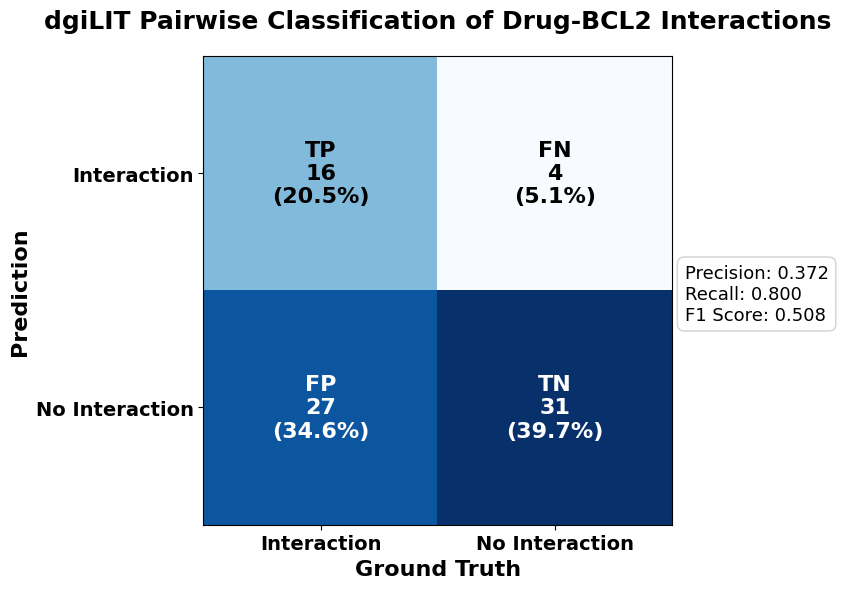

In [16]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------------
# Confusion matrix values
# ------------------------------------------------------------------

tp = ((eval_df["truth"] == True) & (eval_df["predicted"] == True)).sum()
fp = ((eval_df["truth"] == False) & (eval_df["predicted"] == True)).sum()
tn = ((eval_df["truth"] == False) & (eval_df["predicted"] == False)).sum()
fn = ((eval_df["truth"] == True) & (eval_df["predicted"] == False)).sum()

cm = np.array([
    [tp, fn],
    [fp, tn]
])

total = cm.sum()

# ------------------------------------------------------------------
# Metrics
# ------------------------------------------------------------------

precision = tp / (tp + fp) if (tp + fp) else 0
recall = tp / (tp + fn) if (tp + fn) else 0
f1 = (
    2 * precision * recall / (precision + recall)
    if (precision + recall)
    else 0
)

# ------------------------------------------------------------------
# Plot
# ------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(8, 6))

im = ax.imshow(cm, cmap="Blues")

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])

ax.set_xticklabels(
    ["Interaction", "No Interaction"],
    fontsize=14,
    fontweight="bold"
)

ax.set_yticklabels(
    ["Interaction", "No Interaction"],
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel(
    "Ground Truth",
    fontsize=16,
    fontweight="bold"
)

ax.set_ylabel(
    "Prediction",
    fontsize=16,
    fontweight="bold"
)

ax.set_title(
    "dgiLIT Pairwise Classification of Drug-BCL2 Interactions",
    fontsize=18,
    fontweight="bold",
    pad=20,
)

# ------------------------------------------------------------------
# Cell annotations
# ------------------------------------------------------------------

for i in range(2):
    for j in range(2):

        count = cm[i, j]
        pct = (count / total) * 100

        label = (
            "TP" if (i == 0 and j == 0)
            else "FN" if (i == 0 and j == 1)
            else "FP" if (i == 1 and j == 0)
            else "TN"
        )

        ax.text(
            j,
            i,
            f"{label}\n{count}\n({pct:.1f}%)",
            ha="center",
            va="center",
            fontsize=16,
            fontweight="bold",
            color="white" if count > cm.max() * 0.55 else "black",
        )

# ------------------------------------------------------------------
# Metrics box
# ------------------------------------------------------------------

metrics_text = (
    f"Precision: {precision:.3f}\n"
    f"Recall: {recall:.3f}\n"
    f"F1 Score: {f1:.3f}"
)

plt.figtext(
    0.88,
    0.50,
    metrics_text,
    fontsize=13,
    va="center",
    bbox=dict(
        boxstyle="round,pad=0.4",
        facecolor="white",
        edgecolor="lightgray"
    ),
)

# Clean up appearance
ax.set_aspect("equal")

plt.tight_layout()

# Uncomment for manuscript-quality export
# plt.savefig(
#     "bcl2_confusion_matrix.png",
#     dpi=300,
#     bbox_inches="tight"
# )

plt.show()

In [18]:
truth_set = set(
    truth_df.assign(
        drug=lambda x: x["drug_name"].str.upper().str.strip()
    )[["pmid", "drug"]]
    .drop_duplicates()
    .itertuples(index=False, name=None)
)

predicted_set = set(
    pred_df[
        pred_df["interaction"] == True
    ].assign(
        drug=lambda x: x["drug"].str.upper().str.strip()
    )[["pmid", "drug"]]
    .drop_duplicates()
    .itertuples(index=False, name=None)
)

recovered = truth_set & predicted_set

recovery_rate = len(recovered) / len(truth_set)

print(f"Recovered {len(recovered)} of {len(truth_set)} interactions")
print(f"Recovery Rate = {recovery_rate:.1%}")

Recovered 16 of 62 interactions
Recovery Rate = 25.8%


### PRint Outs

In [20]:
import pandas as pd
import numpy as np

# ------------------------------------------------------------------
# Helpers
# ------------------------------------------------------------------

def norm_text(x):
    if pd.isna(x):
        return np.nan
    return str(x).upper().strip()

def candidate_contains_drug(candidate_string, drug):
    if pd.isna(candidate_string) or pd.isna(drug):
        return False

    candidates = {
        norm_text(x)
        for x in str(candidate_string).split(";")
        if str(x).strip()
    }

    return norm_text(drug) in candidates


# ------------------------------------------------------------------
# Normalize truth and prediction data
# ------------------------------------------------------------------

truth_norm = truth_df.copy()
truth_norm["drug"] = truth_norm["drug_name"].map(norm_text)
truth_norm["gene"] = truth_norm["gene_name"].map(norm_text)
truth_norm = truth_norm[truth_norm["gene"] == "BCL2"].copy()

pred_norm = pred_df.copy()
pred_norm["drug"] = pred_norm["drug"].map(norm_text)
pred_norm["gene"] = pred_norm["gene"].map(norm_text)
pred_norm = pred_norm[pred_norm["gene"] == "BCL2"].copy()

# Drop skipped / empty prediction rows
pred_norm = pred_norm.dropna(subset=["pmid", "drug", "gene"])

truth_pairs = (
    truth_norm[["pmid", "drug", "gene"]]
    .drop_duplicates()
    .assign(truth=True)
)

pred_pairs = (
    pred_norm[["pmid", "drug", "gene", "interaction"]]
    .drop_duplicates()
    .rename(columns={"interaction": "predicted"})
)

# ------------------------------------------------------------------
# Build evaluation table
# ------------------------------------------------------------------

eval_full = truth_pairs.merge(
    pred_pairs,
    on=["pmid", "drug", "gene"],
    how="outer"
)

eval_full["truth"] = eval_full["truth"].fillna(False)
eval_full["predicted"] = eval_full["predicted"].fillna(False)

eval_full["classification"] = np.select(
    [
        (eval_full["truth"] == True) & (eval_full["predicted"] == True),
        (eval_full["truth"] == False) & (eval_full["predicted"] == True),
        (eval_full["truth"] == False) & (eval_full["predicted"] == False),
        (eval_full["truth"] == True) & (eval_full["predicted"] == False),
    ],
    ["TP", "FP", "TN", "FN"],
    default="UNKNOWN"
)

# ------------------------------------------------------------------
# Add prediction details
# ------------------------------------------------------------------

pred_details = pred_norm[
    [
        "pmid",
        "block_id",
        "drug",
        "gene",
        "candidate_drugs",
        "candidate_genes",
        "interaction",
        "interaction_type",
        "directionality",
        "evidence",
        "error_message",
    ]
].drop_duplicates(subset=["pmid", "drug", "gene"])

review_df = eval_full.merge(
    pred_details,
    on=["pmid", "drug", "gene"],
    how="left"
)

# Add truth context / metadata
truth_details = truth_norm[
    [
        "pmid",
        "drug",
        "gene",
        "drug_name",
        "gene_name",
        "drug_concept_id",
        "sources",
        "context",
    ]
].drop_duplicates(subset=["pmid", "drug", "gene"])

review_df = review_df.merge(
    truth_details,
    on=["pmid", "drug", "gene"],
    how="left"
)

# If context is missing for FP rows, try to recover PMID-level context from truth_df
pmid_context = (
    truth_norm[["pmid", "context"]]
    .drop_duplicates(subset=["pmid"])
    .rename(columns={"context": "pmid_context"})
)

review_df = review_df.merge(
    pmid_context,
    on="pmid",
    how="left"
)

review_df["review_context"] = review_df["context"].fillna(review_df["pmid_context"])

# Manual review fields
review_df["manual_review"] = ""
review_df["manual_notes"] = ""

# ------------------------------------------------------------------
# FP / FN workbook
# ------------------------------------------------------------------

fp_df = review_df[review_df["classification"] == "FP"].copy()
fn_df = review_df[review_df["classification"] == "FN"].copy()

fp_columns = [
    "classification",
    "pmid",
    "drug",
    "gene",
    "predicted",
    "truth",
    "interaction_type",
    "directionality",
    "evidence",
    "candidate_drugs",
    "candidate_genes",
    "review_context",
    "manual_review",
    "manual_notes",
]

fn_columns = [
    "classification",
    "pmid",
    "drug",
    "gene",
    "predicted",
    "truth",
    "candidate_drugs",
    "candidate_genes",
    "drug_name",
    "drug_concept_id",
    "sources",
    "review_context",
    "manual_review",
    "manual_notes",
]

with pd.ExcelWriter("2026-06-15-bcl2_fp_fn_manual_review.xlsx", engine="xlsxwriter") as writer:
    fp_df[fp_columns].to_excel(writer, sheet_name="False Positives", index=False)
    fn_df[fn_columns].to_excel(writer, sheet_name="False Negatives", index=False)
    review_df.to_excel(writer, sheet_name="All Evaluated Pairs", index=False)

    workbook = writer.book

    for sheet_name in writer.sheets:
        worksheet = writer.sheets[sheet_name]
        worksheet.freeze_panes(1, 0)
        worksheet.autofilter(0, 0, 0, 20)
        worksheet.set_column(0, 5, 14)
        worksheet.set_column(6, 10, 24)
        worksheet.set_column(11, 11, 80)
        worksheet.set_column(12, 13, 24)


# ------------------------------------------------------------------
# Interaction recovery workbook
# ------------------------------------------------------------------

# One row per original truth interaction
recovery_df = truth_norm[
    [
        "pmid",
        "drug",
        "gene",
        "drug_name",
        "gene_name",
        "drug_concept_id",
        "sources",
        "context",
    ]
].drop_duplicates(subset=["pmid", "drug", "gene"]).copy()

# Add candidate drug list per PMID
candidate_by_pmid = (
    pred_norm[["pmid", "candidate_drugs"]]
    .dropna()
    .drop_duplicates(subset=["pmid"])
)

recovery_df = recovery_df.merge(
    candidate_by_pmid,
    on="pmid",
    how="left"
)

recovery_df["candidate_present"] = recovery_df.apply(
    lambda row: candidate_contains_drug(row["candidate_drugs"], row["drug"]),
    axis=1
)

# Add predicted status for exact PMID-drug-BCL2 pair
recovery_df = recovery_df.merge(
    pred_pairs,
    on=["pmid", "drug", "gene"],
    how="left"
)

recovery_df["predicted"] = recovery_df["predicted"].fillna(False)

recovery_df["recovered"] = (
    (recovery_df["candidate_present"] == True)
    & (recovery_df["predicted"] == True)
)

recovery_df["failure_mode"] = np.select(
    [
        recovery_df["recovered"] == True,
        recovery_df["candidate_present"] == False,
        (recovery_df["candidate_present"] == True) & (recovery_df["predicted"] == False),
    ],
    [
        "Recovered",
        "Candidate drug not generated",
        "Candidate generated but classifier returned false",
    ],
    default="Unclear"
)

recovery_df["manual_review"] = ""
recovery_df["manual_notes"] = ""

missed_recovery_df = recovery_df[recovery_df["recovered"] == False].copy()

summary_df = pd.DataFrame(
    {
        "metric": [
            "Total truth interactions",
            "Candidate present",
            "Recovered",
            "Missed",
            "Candidate recall",
            "Interaction recovery rate",
        ],
        "value": [
            len(recovery_df),
            int(recovery_df["candidate_present"].sum()),
            int(recovery_df["recovered"].sum()),
            int((~recovery_df["recovered"]).sum()),
            recovery_df["candidate_present"].mean(),
            recovery_df["recovered"].mean(),
        ],
    }
)

with pd.ExcelWriter("2026-06-15-bcl2_interaction_recovery_review.xlsx", engine="xlsxwriter") as writer:
    summary_df.to_excel(writer, sheet_name="Summary", index=False)
    recovery_df.to_excel(writer, sheet_name="All Truth Interactions", index=False)
    missed_recovery_df.to_excel(writer, sheet_name="Missed Interactions", index=False)

    workbook = writer.book

    for sheet_name in writer.sheets:
        worksheet = writer.sheets[sheet_name]
        worksheet.freeze_panes(1, 0)
        worksheet.autofilter(0, 0, 0, 20)
        worksheet.set_column(0, 8, 18)
        worksheet.set_column(9, 9, 50)
        worksheet.set_column(10, 10, 80)
        worksheet.set_column(11, 15, 24)


print("Saved:")
print("2026-06-15-bcl2_fp_fn_manual_review.xlsx")
print("2026-06-15-bcl2_interaction_recovery_review.xlsx")
print()
print(summary_df)

Saved:
2026-06-15-bcl2_fp_fn_manual_review.xlsx
2026-06-15-bcl2_interaction_recovery_review.xlsx

                      metric      value
0   Total truth interactions  62.000000
1          Candidate present  20.000000
2                  Recovered  16.000000
3                     Missed  46.000000
4           Candidate recall   0.322581
5  Interaction recovery rate   0.258065


/var/folders/5t/sfw5tjx56m10xb861_pd3wfm0000gq/T/ipykernel_76716/1935842880.py:65: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  eval_full["truth"] = eval_full["truth"].fillna(False)
/var/folders/5t/sfw5tjx56m10xb861_pd3wfm0000gq/T/ipykernel_76716/1935842880.py:66: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  eval_full["predicted"] = eval_full["predicted"].fillna(False)
/var/folders/5t/sfw5tjx56m10xb861_pd3wfm0000gq/T/ipykernel_76716/1935842880.py:245: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will chang

### Human Review Scores

In [22]:
review_df = pd.read_excel('2026-06-15-bcl2_fp_fn_manual_review-mc.xlsx',sheet_name='False Positives')
review_df["drug"] = review_df["drug"].str.upper().str.strip()
review_df["gene"] = review_df["gene"].str.upper().str.strip()

human_lookup = review_df[
    ["pmid", "drug", "gene", "human_truth"]
].copy()

eval_human = eval_df.merge(
    human_lookup,
    on=["pmid", "drug", "gene"],
    how="left"
)

eval_human["truth_star"] = eval_human["truth"]

mask = (
    (eval_human["truth"] == False)
    & (eval_human["human_truth"].notna())
)

eval_human.loc[mask, "truth_star"] = (
    eval_human.loc[mask, "human_truth"]
)

tp_star = (
    (eval_human["truth_star"] == True)
    & (eval_human["predicted"] == True)
).sum()

fp_star = (
    (eval_human["truth_star"] == False)
    & (eval_human["predicted"] == True)
).sum()

tn_star = (
    (eval_human["truth_star"] == False)
    & (eval_human["predicted"] == False)
).sum()

fn_star = (
    (eval_human["truth_star"] == True)
    & (eval_human["predicted"] == False)
).sum()


/var/folders/5t/sfw5tjx56m10xb861_pd3wfm0000gq/T/ipykernel_76716/523155206.py:22: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[True True True True True True True True True True True True True True
 True True True True True True True True True True True True False]' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  eval_human.loc[mask, "truth_star"] = (


TP*: 42
FP*: 1
TN*: 31
FN*: 4


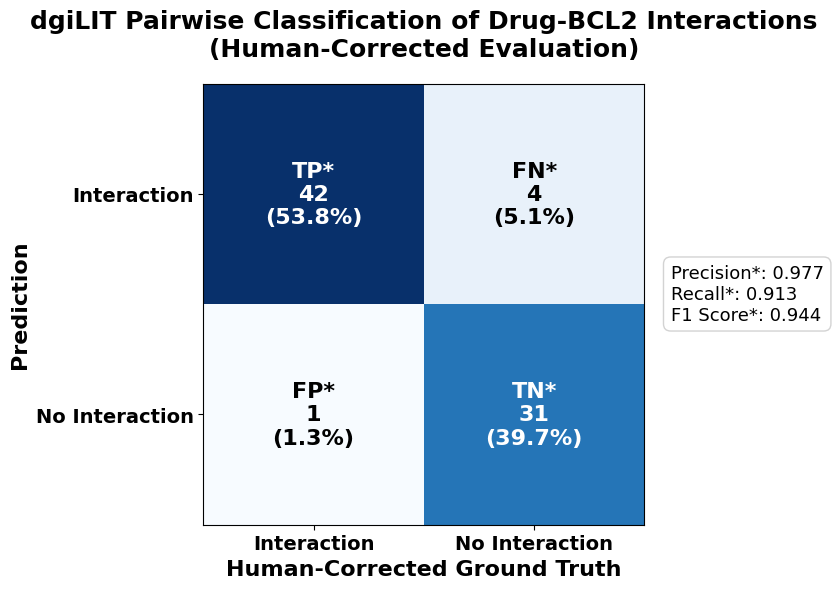

In [23]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------------
# Human-corrected confusion matrix values
# ------------------------------------------------------------------

tp_star = (
    (eval_human["truth_star"] == True)
    & (eval_human["predicted"] == True)
).sum()

fp_star = (
    (eval_human["truth_star"] == False)
    & (eval_human["predicted"] == True)
).sum()

tn_star = (
    (eval_human["truth_star"] == False)
    & (eval_human["predicted"] == False)
).sum()

fn_star = (
    (eval_human["truth_star"] == True)
    & (eval_human["predicted"] == False)
).sum()

print(
    f"TP*: {tp_star}\n"
    f"FP*: {fp_star}\n"
    f"TN*: {tn_star}\n"
    f"FN*: {fn_star}"
)

cm = np.array([
    [tp_star, fn_star],
    [fp_star, tn_star]
])

total = cm.sum()

# ------------------------------------------------------------------
# Metrics
# ------------------------------------------------------------------

precision_star = (
    tp_star / (tp_star + fp_star)
    if (tp_star + fp_star)
    else 0
)

recall_star = (
    tp_star / (tp_star + fn_star)
    if (tp_star + fn_star)
    else 0
)

f1_star = (
    2 * precision_star * recall_star
    / (precision_star + recall_star)
    if (precision_star + recall_star)
    else 0
)

# ------------------------------------------------------------------
# Plot
# ------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(8, 6))

im = ax.imshow(cm, cmap="Blues")

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])

ax.set_xticklabels(
    ["Interaction", "No Interaction"],
    fontsize=14,
    fontweight="bold"
)

ax.set_yticklabels(
    ["Interaction", "No Interaction"],
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel(
    "Human-Corrected Ground Truth",
    fontsize=16,
    fontweight="bold"
)

ax.set_ylabel(
    "Prediction",
    fontsize=16,
    fontweight="bold"
)

ax.set_title(
    "dgiLIT Pairwise Classification of Drug-BCL2 Interactions\n(Human-Corrected Evaluation)",
    fontsize=18,
    fontweight="bold",
    pad=20,
)

# ------------------------------------------------------------------
# Cell annotations
# ------------------------------------------------------------------

for i in range(2):
    for j in range(2):

        count = cm[i, j]
        pct = (count / total) * 100

        label = (
            "TP*" if (i == 0 and j == 0)
            else "FN*" if (i == 0 and j == 1)
            else "FP*" if (i == 1 and j == 0)
            else "TN*"
        )

        ax.text(
            j,
            i,
            f"{label}\n{count}\n({pct:.1f}%)",
            ha="center",
            va="center",
            fontsize=16,
            fontweight="bold",
            color="white" if count > cm.max() * 0.55 else "black",
        )

# ------------------------------------------------------------------
# Metrics box
# ------------------------------------------------------------------

metrics_text = (
    f"Precision*: {precision_star:.3f}\n"
    f"Recall*: {recall_star:.3f}\n"
    f"F1 Score*: {f1_star:.3f}"
)

plt.figtext(
    0.88,
    0.50,
    metrics_text,
    fontsize=13,
    va="center",
    bbox=dict(
        boxstyle="round,pad=0.4",
        facecolor="white",
        edgecolor="lightgray"
    ),
)

ax.set_aspect("equal")

plt.tight_layout()

# Uncomment to save
# plt.savefig(
#     "bcl2_confusion_matrix_human_corrected.png",
#     dpi=300,
#     bbox_inches="tight"
# )

plt.show()